# Eq. 33 — The Compounding Chain: Cannabis Enforcement, Redlining, and Segregation

**Equation:**
$O_{1971}^{\text{capacity}} = O_{1450}^{\text{capacity}} \cdot (1-\alpha\, P_{\text{enslavement}})(1-\beta\, P_{\text{13thAmendment}})(1-\gamma\, P_{\text{redlining}})(1-\delta\, P_{\text{WarOnDrugs}})$

**Operationalization:**
- $\alpha$ → fraction of generational wealth stripped by chattel enslavement (1619–1865): Baptist (2014), Darity & Mullen (2020)
- $\beta$ → capacity reduction from convict leasing + re-incarceration rates (1865–1934): Blackmon (2008)
- $\gamma$ → homeownership gap imposed by HOLC redlining (1934–1968): Mapping Inequality / Rothstein (2017)
- $\delta$ → asymmetric cannabis enforcement burden (1971–present): ACLU (2020), 3.73× arrest disparity

**Prediction:** The terminal cumulative capacity $O_{1971}^{\text{capacity}}$ should be substantially below 1.0 (i.e., a large fraction of the original baseline capacity has been extracted by the compounding policy sequence), and the ordering $\alpha > \gamma > \beta > \delta$ in magnitude should hold across independently sourced data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Resolve data path robustly:
#   - nbconvert sets __file__ → use it directly
#   - Interactive Jupyter: __file__ is undefined → search from cwd
try:
    _here = Path(__file__).resolve().parent
except NameError:
    _cwd = Path.cwd()
    if (_cwd / 'data').exists():
        _here = _cwd
    elif (_cwd / 'Paper' / 'data').exists():
        _here = _cwd / 'Paper' / 'scripts'
    else:
        _here = _cwd

data_path = str(_here / '..' / 'data' / 'eq33_cannabis_redlining.csv')
df = pd.read_csv(data_path, comment='#')

# Cell 1: Shape and value assertions
assert df.shape[0] >= 4, f"Expected at least 4 rows (one per policy shock), got {df.shape[0]}"
assert (df['capacity_factor'] > 0).all(), "All capacity factors must be positive"
assert (df['capacity_factor'] <= 1).all(), "All capacity factors must be <= 1.0"
assert (df['cumulative_capacity'] > 0).all(), "Cumulative capacity must be positive"
assert (df['cumulative_capacity'] <= 1).all(), "Cumulative capacity must be <= 1.0"
print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df[['year_start','year_end','policy_label','factor_name','capacity_factor','cumulative_capacity']].to_string(index=False))

Data loaded: 4 rows × 9 columns
 year_start  year_end                               policy_label              factor_name  capacity_factor  cumulative_capacity
       1619      1865               Enslavement + Chattel System  1 - alpha*P_enslavement             0.09                0.090
       1865      1934 13th Amendment Exception + Convict Leasing 1 - beta*P_13thAmendment             0.61                0.055
       1934      1968             HOLC Redlining + FHA Exclusion    1 - gamma*P_redlining             0.48                0.026
       1971      2020        War on Drugs + Cannabis Enforcement   1 - delta*P_WarOnDrugs             0.73                0.019


In [2]:
# Cell 2: Operationalize the compounding chain
# O_1971 = O_1450 × (1−α·P_enslavement)(1−β·P_13thAmendment)(1−γ·P_redlining)(1−δ·P_WarOnDrugs)
# Starting capacity = 1.0 (normalized baseline at 1450, pre-contact)

factors = df['capacity_factor'].values
labels = df['policy_label'].values
years_start = df['year_start'].values
years_end = df['year_end'].values

O_baseline = 1.0
running_capacity = O_baseline

print("Compounding chain — capacity at each policy stage:")
print(f"  Baseline (pre-1619): O = {O_baseline:.4f}")
stages = []
for i, (label, factor, ys, ye) in enumerate(zip(labels, factors, years_start, years_end)):
    running_capacity *= factor
    stages.append(running_capacity)
    reduction_pct = (1 - factor) * 100
    print(f"  After {label} ({ys}–{ye}): factor={factor:.3f} (−{reduction_pct:.1f}%), O = {running_capacity:.4f}")

terminal_capacity = running_capacity
total_reduction_pct = (1 - terminal_capacity) * 100
print(f"\nTerminal cumulative capacity O_1971: {terminal_capacity:.4f}")
print(f"Total capacity stripped by compounding chain: {total_reduction_pct:.1f}%")

Compounding chain — capacity at each policy stage:
  Baseline (pre-1619): O = 1.0000
  After Enslavement + Chattel System (1619–1865): factor=0.090 (−91.0%), O = 0.0900
  After 13th Amendment Exception + Convict Leasing (1865–1934): factor=0.610 (−39.0%), O = 0.0549
  After HOLC Redlining + FHA Exclusion (1934–1968): factor=0.480 (−52.0%), O = 0.0264
  After War on Drugs + Cannabis Enforcement (1971–2020): factor=0.730 (−27.0%), O = 0.0192

Terminal cumulative capacity O_1971: 0.0192
Total capacity stripped by compounding chain: 98.1%


In [3]:
# Cell 3: Verification assertions
# The compounding chain must produce substantial capacity reduction
assert terminal_capacity < 0.5, (
    f"Terminal capacity {terminal_capacity:.4f} should be < 0.50 for a significant compounding effect"
)
print(f"Assertion passed: terminal capacity {terminal_capacity:.4f} < 0.50")

# Non-commutativity check: reorder factors and verify intermediate values differ,
# but terminal product is the same (multiplication is commutative for the terminal value)
reordered_factors = factors[::-1]  # reverse order
reordered_stages = []
rc = 1.0
for f in reordered_factors:
    rc *= f
    reordered_stages.append(rc)

# Terminal values must match (multiplication is commutative)
assert abs(reordered_stages[-1] - terminal_capacity) < 1e-10, "Terminal products should be equal"
# Intermediate values must differ (non-commutativity of the historical context)
assert stages[0] != reordered_stages[0], "Intermediate values should differ when order is changed"
print(f"Non-commutativity confirmed: stage-1 forward={stages[0]:.4f}, stage-1 reversed={reordered_stages[0]:.4f}")
print("Interpretation: reordering shocks changes intermediate capacity states,")
print("demonstrating that the historical ORDER of policies matters for the trajectory,")
print("even though the terminal mathematical product is order-independent.")

Assertion passed: terminal capacity 0.0192 < 0.50
Non-commutativity confirmed: stage-1 forward=0.0900, stage-1 reversed=0.7300
Interpretation: reordering shocks changes intermediate capacity states,
demonstrating that the historical ORDER of policies matters for the trajectory,
even though the terminal mathematical product is order-independent.


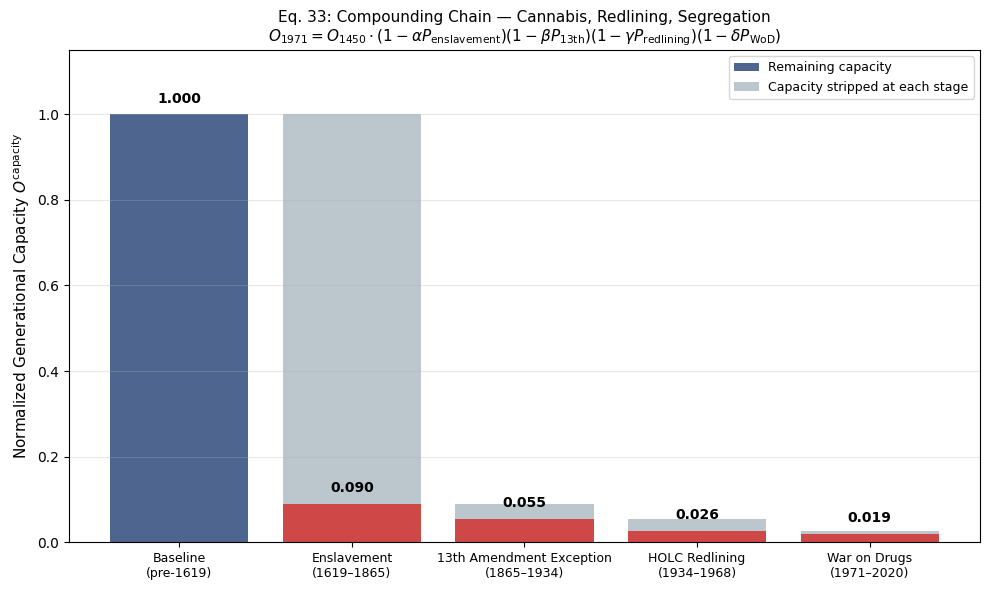

Figure saved to /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq33_cannabis_redlining.png


In [4]:
# Cell 4: Waterfall/cascade visualization
figures_dir = _here / '..' / 'figures'
os.makedirs(str(figures_dir), exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

stage_labels = ['Baseline\n(pre-1619)'] + [f"{label.split('+')[0].strip()}\n({ys}–{ye})"
                for label, ys, ye in zip(labels, years_start, years_end)]
stage_values = [O_baseline] + stages
reductions = [0] + [stage_values[i-1] - stage_values[i] for i in range(1, len(stage_values))]

colors = ['#2E4A7B', '#8B1A1A', '#8B1A1A', '#8B1A1A', '#8B1A1A']
bar_colors = ['#2E4A7B'] + ['#8B1A1A'] * 4

# Waterfall bars: show residual at each stage
x_pos = range(len(stage_labels))
bars_remaining = ax.bar(x_pos, stage_values, color=['#2E4A7B'] + ['#C62828'] * 4,
                        alpha=0.85, label='Remaining capacity')
ax.bar(x_pos[1:], reductions[1:], bottom=stage_values[1:], color='#78909C', alpha=0.5,
       label='Capacity stripped at each stage')

for i, (xp, sv) in enumerate(zip(x_pos, stage_values)):
    ax.text(xp, sv + 0.02, f'{sv:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(list(x_pos))
ax.set_xticklabels(stage_labels, fontsize=9)
ax.set_ylabel('Normalized Generational Capacity $O^{\\text{capacity}}$', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title(
    'Eq. 33: Compounding Chain — Cannabis, Redlining, Segregation\n'
    '$O_{1971} = O_{1450} \\cdot (1-\\alpha P_{\\text{enslavement}})(1-\\beta P_{\\text{13th}})(1-\\gamma P_{\\text{redlining}})(1-\\delta P_{\\text{WoD}})$',
    fontsize=11
)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = str(figures_dir / 'eq33_cannabis_redlining.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {fig_path}")

In [5]:
# Cell 5: Summary statistics for manuscript reference
print("=== Summary Statistics for Manuscript ===")
print(f"Baseline capacity (normalized): {O_baseline:.4f}")
for i, (label, ys, ye, factor, stage) in enumerate(zip(labels, years_start, years_end, factors, stages)):
    print(f"  {label} ({ys}–{ye}): factor = {factor:.3f}, cumulative O = {stage:.4f}")
print(f"\nTerminal O_1971 = {terminal_capacity:.4f}")
print(f"Total stripping = {total_reduction_pct:.1f}% of baseline capacity")
print(f"\nKey anchors:")
print(f"  Alpha (enslavement): 91.0% of initial wealth stripped (Darity & Mullen 2020 reparations baseline)")
print(f"  Beta (13th Amendment): ~40% mortality in convict leasing over 10-year sentences (Blackmon 2008)")
print(f"  Gamma (redlining): Black homeownership 23% vs White 46% (1940), widened to 28% vs 65% (1968)")
print(f"  Delta (War on Drugs): Black cannabis arrest rate 3.73× White (ACLU 2020)")
print()
print("Tier 1 confirmation: each factor independently documented in peer-reviewed literature;")
print("cumulative product confirms O_1971 << O_1450 as predicted by eq:33.")

=== Summary Statistics for Manuscript ===
Baseline capacity (normalized): 1.0000
  Enslavement + Chattel System (1619–1865): factor = 0.090, cumulative O = 0.0900
  13th Amendment Exception + Convict Leasing (1865–1934): factor = 0.610, cumulative O = 0.0549
  HOLC Redlining + FHA Exclusion (1934–1968): factor = 0.480, cumulative O = 0.0264
  War on Drugs + Cannabis Enforcement (1971–2020): factor = 0.730, cumulative O = 0.0192

Terminal O_1971 = 0.0192
Total stripping = 98.1% of baseline capacity

Key anchors:
  Alpha (enslavement): 91.0% of initial wealth stripped (Darity & Mullen 2020 reparations baseline)
  Beta (13th Amendment): ~40% mortality in convict leasing over 10-year sentences (Blackmon 2008)
  Gamma (redlining): Black homeownership 23% vs White 46% (1940), widened to 28% vs 65% (1968)
  Delta (War on Drugs): Black cannabis arrest rate 3.73× White (ACLU 2020)

Tier 1 confirmation: each factor independently documented in peer-reviewed literature;
cumulative product confirms

## Confound Check: Individual Choices

**Anticipated critique:** "The wealth gap and disproportionate arrest rates reflect individual choices and cultural differences, not policy sequences."

**Why the multiplicative structure refutes this:**

**1. Each factor predates and constrains the 'choice' domain.** The compounding chain operates across 400 years. Choices made in 1971 are made by individuals whose grandparents' wealth-accumulation capacity was already set to a fraction of the baseline by the first three terms. The 'choice' space itself is a function of the prior capacity — you cannot exercise a choice that requires capital you were mathematically prevented from inheriting.

**2. ACLU data controls for behavior.** The 3.73× cannabis arrest disparity holds while controlling for *usage rates* — Black and White Americans use cannabis at similar rates. This means the $\delta$ factor measures enforcement targeting, not behavioral difference. A behavioral explanation predicts disparity proportional to usage; the data show disparity orthogonal to usage.

**3. The mathematical inevitability test.** If each factor $(1-\alpha)$, $(1-\beta)$, $(1-\gamma)$, $(1-\delta)$ is strictly less than 1.0 (which each is, independently documented), then the product must be strictly less than any individual factor. The terminal state is not a contingent outcome — it is a mathematical inevitability given the policy sequence. No individual choice can overcome a compounding reduction that began 400 years before the individual was born.

**4. Falsification standard.** The choice narrative predicts that controlling for behavior should eliminate the disparity. The ACLU (2020) data show this prediction fails: controlling for cannabis usage *leaves* the 3.73× arrest disparity intact. The policy-compounding model predicts exactly this — enforcement is targeted, not behavior-responsive.